## 03a Experiment 1b - Family Resemblance

In [ ]:
# Setup
import pandas as pd
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast
import numpy as np
from collections import defaultdict
from matplotlib.ticker import MaxNLocator
from matplotlib.cm import get_cmap

In [ ]:
# Import Data

attributes_df  = pd.read_csv('01_catmemexp_attributestask_allmodels_processed.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding = "utf-8")
attributes_df.head()

In [3]:
attributes_df['output_list_processed_nonoise'] = attributes_df['output_list_processed_nonoise'].apply(ast.literal_eval)

In [4]:
attributes_df.loc[attributes_df['model'] == 'deepseek-chat', 'model'] = 'DeepSeek'
attributes_df.loc[attributes_df['model'] == 'gemini-3-pro', 'model'] = 'Gemini 3 Pro'
attributes_df.loc[attributes_df['model'] == 'gpt-5.2', 'model'] = 'GPT-5.2'

#### Properties

In [5]:
# PROPERTY 1: FAMILY RESEMBLANCE

#There is no set of necessary and sufficient conditions for category membership, instead there are salient features for each category and members of a category share salient features of the category, 
# but not all members need to possess every feature. 

# 1. To individuate the most salient features of each category we take the top-k listed attributes for each category member in each category from the Attributes-task in Step 1
# --> If Prototypical, Should there be a prototypical effect, we should not see any salient common feature across listed members

# 2. We analyse the distribution of the attributes across category members within categories
# --> If Prototypical, Attributes should not have a uniform or near-uniform frequency distribution

In [6]:
# 1. 

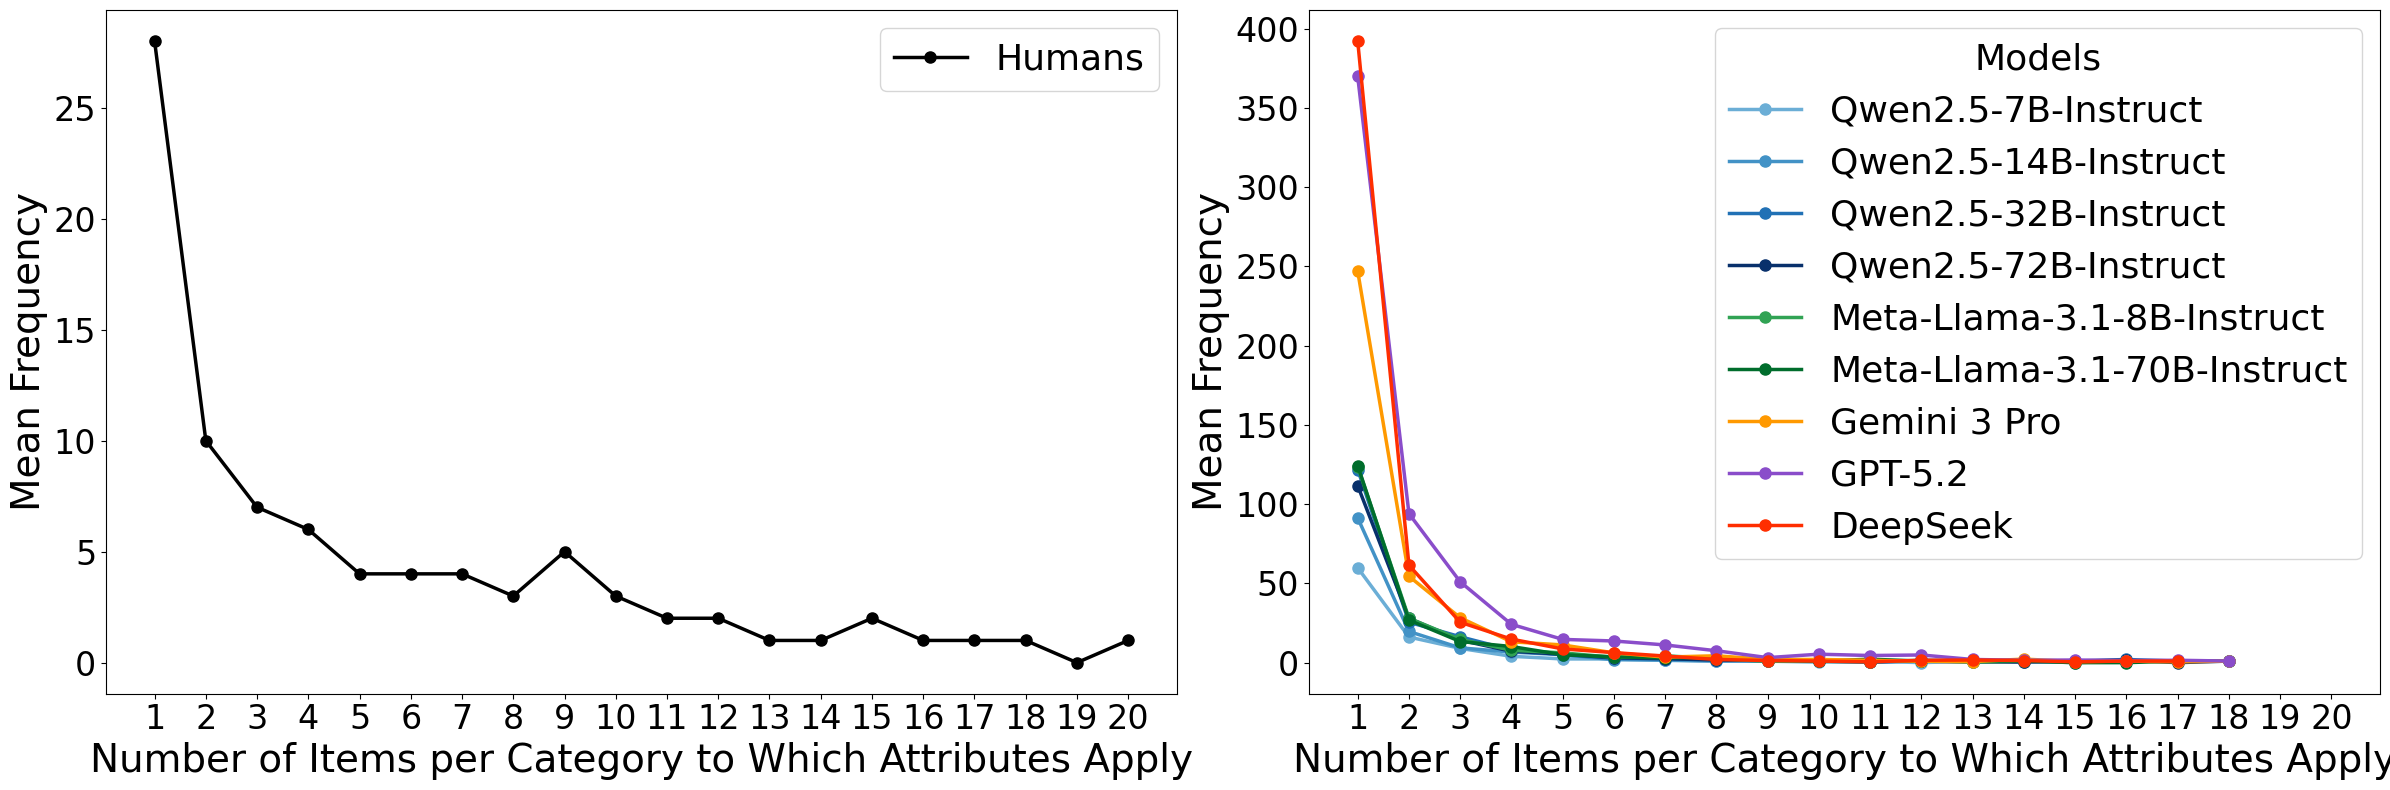

In [ ]:
model_palette = {
    'Qwen2.5-7B-Instruct': '#6baed6',
    'Qwen2.5-14B-Instruct': '#4292c6',
    'Qwen2.5-32B-Instruct': '#2171b5',
    'Qwen2.5-72B-Instruct': '#08306b',
    'Meta-Llama-3.1-8B-Instruct': '#31a354',
    'Meta-Llama-3.1-70B-Instruct': '#006d2c',
    'DeepSeek': '#ff2e00',
    'Gemini 3 Pro': '#ff9900',
    'GPT-5.2': '#8a4dca'
}

unique_models = attributes_df['model'].unique()
unique_categories = attributes_df['category'].unique()

fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(24, 8), sharex=True)

humans_x = np.arange(1, 21)
humans_y = [28, 10, 7, 6, 4, 4, 4, 3, 5, 3, 2, 2, 1, 1, 2, 1, 1, 1, 0, 1]
ax2.plot(humans_x, humans_y, marker='o', linestyle='-', label='Humans', color='black', linewidth=2.5, markersize=8)

for model_name in unique_models:
    model_counts = []

    for category_name in unique_categories:

        filtered_df = attributes_df[
            (attributes_df['model'] == model_name) & 
            (attributes_df['category'] == category_name)
        ]

        attribute_item_counts = {}

        unique_items = filtered_df['item'].unique()

        for item in unique_items:

            item_attributes = filtered_df[filtered_df['item'] == item]['output_list_processed_nonoise'].values

            attributes = [attr for row in item_attributes for attr in row]

            for attr in set(attributes):
                if attr in attribute_item_counts:
                    attribute_item_counts[attr].add(item)
                else:
                    attribute_item_counts[attr] = {item}

        for attr in attribute_item_counts:
            attribute_item_counts[attr] = len(attribute_item_counts[attr])

        item_count_distribution = {}
        for count in attribute_item_counts.values():
            item_count_distribution[count] = item_count_distribution.get(count, 0) + 1

        attribute_counts = [item_count_distribution.get(i, 0) for i in range(max(item_count_distribution.keys()) + 1)]
        model_counts.append(attribute_counts)

    average_counts = [np.mean([counts[i] for counts in model_counts if i < len(counts)]) for i in range(max(len(c) for c in model_counts))]

    item_counts_full = np.arange(1, len(average_counts) + 1) 

    ax1.plot(item_counts_full[:-1], average_counts[1:], marker='o', linestyle='-', 
             label=model_name, color=model_palette.get(model_name, 'black'), 
             linewidth=2.5, markersize=8)

ax1.set_ylabel('Mean Frequency', fontsize=28)
ax1.set_xlabel('Number of Items per Category to Which Attributes Apply', fontsize=28)
ax2.set_xlabel('Number of Items per Category to Which Attributes Apply', fontsize=28)
ax2.set_ylabel('Mean Frequency', fontsize=28)

ax2.set_xticks(np.linspace(1, 20, num=20))  
ax1.set_xticks(np.linspace(1, 20, num=20))  
ax1.tick_params(axis='both', labelsize=24)
ax2.tick_params(axis='both', labelsize=24)

ax1.legend(title='Models', fontsize=26, title_fontsize=26)
ax2.legend(fontsize=26)

plt.grid(False)
plt.tight_layout()
plt.savefig('03_PropertiesFigures/figure_family_resemblance.pdf', format='pdf')
plt.show()


In [ ]:
unique_models = attributes_df['model'].unique()
unique_categories = attributes_df['category'].unique()

for model_name in unique_models:
   
    n_categories = len(unique_categories)
    ncols = 2
    nrows = (n_categories + ncols - 1) // ncols  
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, nrows * 4))
    axs = axs.flatten()  

    for i, category_name in enumerate(unique_categories):
 
        filtered_df = attributes_df[
            (attributes_df['model'] == model_name) & 
            (attributes_df['category'] == category_name)
        ]

        attribute_item_counts = {}

        unique_items = filtered_df['item'].unique()

        for item in unique_items:

            item_attributes = filtered_df[filtered_df['item'] == item]['output_list_processed_nonoise'].values

            attributes = [attr for row in item_attributes for attr in row]

            for attr in set(attributes):  
                if attr in attribute_item_counts:
                    attribute_item_counts[attr].add(item)  
                else:
                    attribute_item_counts[attr] = {item}  

        for attr in attribute_item_counts:
            attribute_item_counts[attr] = len(attribute_item_counts[attr])  

        item_count_distribution = {}
        for count in attribute_item_counts.values():
            if count in item_count_distribution:
                item_count_distribution[count] += 1  
            else:
                item_count_distribution[count] = 1  

        item_counts = sorted(item_count_distribution.keys())
        attribute_counts = [item_count_distribution[count] for count in item_counts]

        ax = axs[i]
        ax.plot(item_counts, attribute_counts, marker='o', linestyle='-', color='black')
        ax.set_title(f'{model_name} - {category_name}')
        ax.set_xlabel('Number of Items per Category to Which Attributes Apply')
        ax.set_ylabel('Frequency (Number of Attributes)')
        ax.set_xticks(item_counts)  
        ax.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    for j in range(n_categories, nrows * ncols):
        fig.delaxes(axs[j])

    plt.tight_layout()
    plt.savefig(f'03_PropertiesFigures/{model_name}_item_count_distribution_plot.pdf', format='pdf')
    plt.show()


C:\Users\AS\AppData\Local\Temp\ipykernel_13596\1780991954.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = get_cmap('tab10').colors


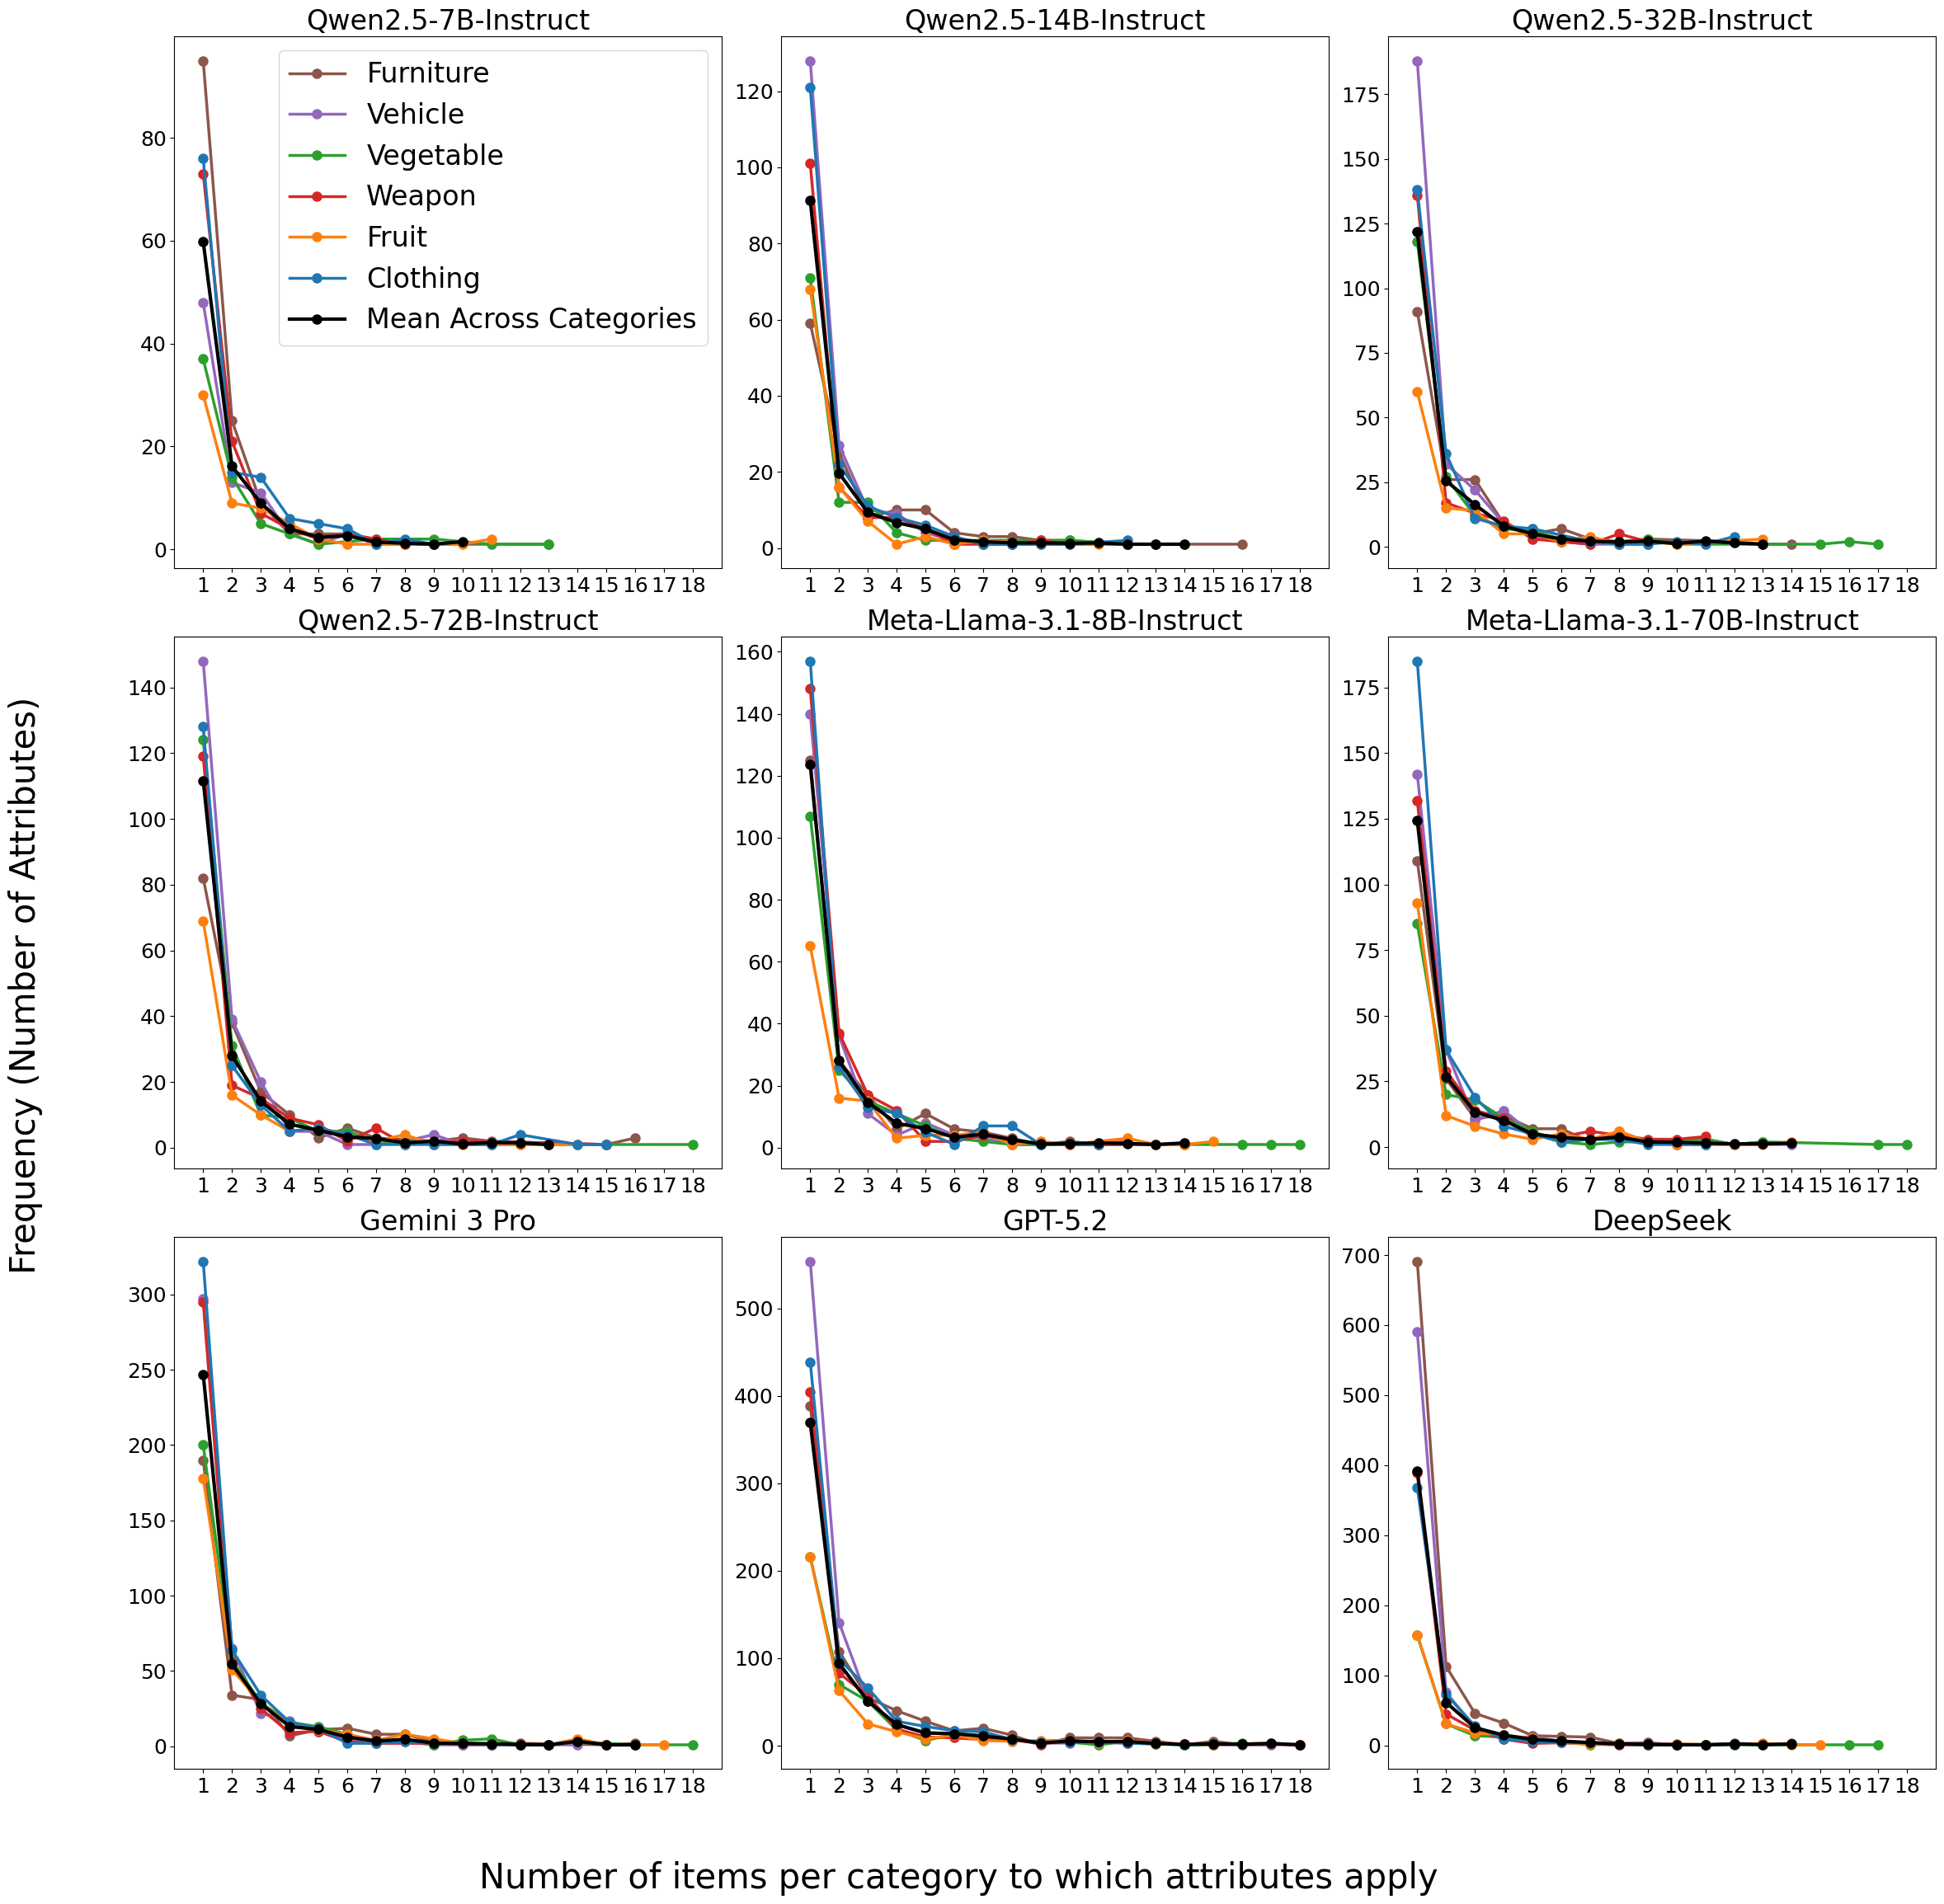

In [ ]:
unique_models = attributes_df['model'].unique()
unique_categories = attributes_df['category'].unique()

tab10 = get_cmap('tab10').colors
category_color_map = {
    'Vegetable': tab10[2],
    'Furniture': tab10[5],
    'Weapon': tab10[3],
    'Fruit': tab10[1],
    'Clothing': tab10[0],
    'Vehicle': tab10[4],
}

n_models = len(unique_models)
ncols = 3
nrows = 3
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(24, nrows * 8))
axs = axs.flatten()

for idx, model_name in enumerate(unique_models):
    all_item_counts = []
    all_attribute_counts = []

    for category_name in unique_categories:
        filtered_df = attributes_df[
            (attributes_df['model'] == model_name) &
            (attributes_df['category'] == category_name)
        ]

        attribute_item_counts = {}
        unique_items = filtered_df['item'].unique()

        for item in unique_items:
            item_attributes = filtered_df[
                filtered_df['item'] == item
            ]['output_list_processed_nonoise'].values

            attributes = [attr for row in item_attributes for attr in row]

            for attr in set(attributes):
                if attr in attribute_item_counts:
                    attribute_item_counts[attr].add(item)
                else:
                    attribute_item_counts[attr] = {item}

        for attr in attribute_item_counts:
            attribute_item_counts[attr] = len(attribute_item_counts[attr])

        item_count_distribution = {}
        for count in attribute_item_counts.values():
            item_count_distribution[count] = item_count_distribution.get(count, 0) + 1

        item_counts = sorted(item_count_distribution.keys())
        attribute_counts = [item_count_distribution[c] for c in item_counts]

        all_item_counts.append(item_counts)
        all_attribute_counts.append(attribute_counts)

        axs[idx].plot(
            item_counts,
            attribute_counts,
            marker='o',
            linestyle='-',
            linewidth=2.5,
            markersize=8,
            label=category_name,
            color=category_color_map.get(category_name, 'gray')
        )

    max_length = max((len(x) for x in all_item_counts), default=0)
    mean_attribute_counts = []

    for i in range(max_length):
        vals = [
            all_attribute_counts[j][i]
            for j in range(len(all_item_counts))
            if i < len(all_item_counts[j])
        ]
        mean_attribute_counts.append(np.mean(vals) if vals else 0)

    if max_length > 0:
        mean_x = np.arange(1, max_length + 1)
        axs[idx].plot(
            mean_x,
            mean_attribute_counts,
            marker='o',
            linestyle='-',
            linewidth=3,
            markersize=8,
            color='black',
            label='Mean Across Categories'
        )

    axs[idx].set_xticks(range(1, 19))
    axs[idx].set_xlim(0, 19)

    axs[idx].set_title(model_name, fontsize=24)
    axs[idx].tick_params(axis='both', labelsize=18)
    axs[idx].grid(False)

    if idx == 0:
        axs[idx].legend(fontsize=24, title_fontsize=30)
    else:
        axs[idx].legend().remove()

for j in range(n_models, nrows * ncols):
    fig.delaxes(axs[j])

fig.supxlabel(
    'Number of items per category to which attributes apply',
    fontsize=30,
    y=0.04
)
fig.supylabel(
    'Frequency (Number of Attributes)',
    fontsize=30,
    x=0.02
)

plt.tight_layout(rect=[0.05, 0.06, 1, 1])
plt.savefig('03_PropertiesFigures/appendix_figure_family_resemblance_breakdown.pdf', format='pdf')
plt.show()

In [ ]:
unique_models = attributes_df['model'].unique()
unique_categories = attributes_df['category'].unique()

n_models = len(unique_models)
ncols = 3
nrows = 3 
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, nrows * 6))

axs = axs.flatten()

for idx, model_name in enumerate(unique_models):

    all_item_counts = []
    all_attribute_counts = []

    for category_name in unique_categories:
        filtered_df = attributes_df[
            (attributes_df['model'] == model_name) & 
            (attributes_df['category'] == category_name)
        ]

        attribute_item_counts = {}

        unique_items = filtered_df['item'].unique()

        for item in unique_items:
 
            item_attributes = filtered_df[filtered_df['item'] == item]['output_list_processed_nonoise'].values

            attributes = [attr for row in item_attributes for attr in row]

            for attr in set(attributes):
                if attr in attribute_item_counts:
                    attribute_item_counts[attr].add(item)
                else:
                    attribute_item_counts[attr] = {item}

        for attr in attribute_item_counts:
            attribute_item_counts[attr] = len(attribute_item_counts[attr])

        item_count_distribution = {}
        for count in attribute_item_counts.values():
            if count in item_count_distribution:
                item_count_distribution[count] += 1
            else:
                item_count_distribution[count] = 1

        item_counts = sorted(item_count_distribution.keys())
        attribute_counts = [item_count_distribution[count] for count in item_counts]

        all_item_counts.append(item_counts)
        all_attribute_counts.append(attribute_counts)

        axs[idx].plot(item_counts, attribute_counts, marker='o', linestyle='-', label=category_name)

    max_length = max(len(x) for x in all_item_counts)
    mean_attribute_counts = []

    for i in range(max_length):
        count_values = []
        for j in range(len(all_item_counts)):
            if i < len(all_item_counts[j]):
                count_values.append(all_attribute_counts[j][i])
        mean_attribute_counts.append(np.mean(count_values) if count_values else 0)

    mean_x = np.arange(1, max_length + 1)  

    axs[idx].plot(mean_x, mean_attribute_counts, marker='o', linestyle='-', color='black', label='Mean Across Categories')

    axs[idx].set_title(f'{model_name}')
    axs[idx].set_xlabel('Number of items per category to which attributes apply')
    axs[idx].set_ylabel('Frequency (Number of Attributes)')
    axs[idx].set_xticks(range(1, max_length + 1))  
    axs[idx].grid(False)
    axs[idx].legend()

for j in range(n_models, nrows * ncols):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.savefig('03_PropertiesFigures/combined_item_count_distribution_plot.pdf', format='pdf')
plt.show()


In [ ]:
# Common Attributes Within Categories Heatmap

unique_models = attributes_df['model'].unique()
unique_categories = attributes_df['category'].unique()

common_attributes_counts = {model: {} for model in unique_models}

for model in unique_models:
    
    for category in unique_categories:
        
        filtered_df = attributes_df[
            (attributes_df['category'] == category) & 
            (attributes_df['model'] == model)
        ]

        
        unique_items = filtered_df['item'].unique()
        
        if unique_items.size > 0:
            
            common_attributes = None
            
            for item in unique_items:
                
                item_attributes = filtered_df[filtered_df['item'] == item]['output_list_processed_nonoise'].values

                attributes = [attr for row in item_attributes for attr in row]

                attribute_set = set(attributes)

                if common_attributes is None:
                    common_attributes = attribute_set
                else:
                    common_attributes &= attribute_set

            common_attributes_counts[model][category] = len(common_attributes)
        else:
            common_attributes_counts[model][category] = 0  

heatmap_data = pd.DataFrame(common_attributes_counts).T  

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='coolwarm', cbar_kws={'label': 'Number of Common Attributes'})

plt.xlabel('Categories')
plt.ylabel('Models')

plt.savefig('03_PropertiesFigures/common_attributes_heatmap.pdf', format='pdf')
plt.show()

for model in unique_models:
    print(f"\nCommon Attributes for {model}:")
    for category in common_attributes_counts[model]: 
        print(f"  {category}: {common_attributes_counts[model][category]} common attributes")


In [ ]:
# 2.

In [ ]:
# Attribute Frequency Histograms

unique_models = attributes_df['model'].unique()

for model in unique_models:
    unique_categories = attributes_df['category'].unique()
    
    ncols = 3  
    nrows = 6 

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 24), sharey=True)

    for category_index, category in enumerate(unique_categories):
        for frequency_type_index, frequency_type in enumerate(['most_frequent', 'average_frequency', 'least_frequent']):
            filtered_df = attributes_df[
                (attributes_df['frequency'] == frequency_type) &
                (attributes_df['category'] == category) &
                (attributes_df['model'] == model)
            ]

            unique_items = filtered_df['item'].unique()
            all_counts = []

            for item in unique_items:
                attributes = []
                item_attributes = filtered_df[filtered_df['item'] == item]['output_list_processed_nonoise'].values
                
                for row in item_attributes:
                    attributes.extend(row)

                attribute_counts = Counter(attributes)

                sorted_attributes = sorted(attribute_counts.items(), key=lambda pair: pair[1], reverse=True)

                frequency_index_mapping = {attribute: index for index, (attribute, _) in enumerate(sorted_attributes)}

                renaming_map = {attribute: f'attr_{index}' for attribute, index in frequency_index_mapping.items()}

                counts = [count for _, count in sorted_attributes]
                all_counts.append((renaming_map, counts))

            cmap = plt.get_cmap('viridis', len(unique_items))

            for index, (renaming_map, counts) in enumerate(all_counts):
                keys = [renaming_map[key] for key in renaming_map.keys()]

                axs[category_index, frequency_type_index].bar(keys, counts, color=cmap(index), 
                                                              alpha=0.7, label=f'{unique_items[index]}', align='center')

            axs[category_index, frequency_type_index].set_title(f'{category} - {frequency_type}')
            axs[category_index, frequency_type_index].set_ylabel('Frequency')
            axs[category_index, frequency_type_index].set_xlabel('Attributes')

            axs[category_index, frequency_type_index].set_xticks([])
            axs[category_index, frequency_type_index].legend()

    for i in range(len(unique_categories), nrows):
        for j in range(ncols):
            fig.delaxes(axs[i, j])

    fig.suptitle(f'{model}', fontsize=20)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  
    plt.savefig(f'03_PropertiesFigures/{model}_attributes_freqdist_nonoise.pdf', format='pdf')
    plt.show()


In [ ]:
unique_models = attributes_df['model'].unique()

for model in unique_models:
   
    unique_categories = attributes_df['category'].unique()

    ncols = 3  
    nrows = 6  

    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 24), constrained_layout=True)

    for category_index, category in enumerate(unique_categories):
        for frequency_type_index, frequency_type in enumerate(['most_frequent', 'average_frequency', 'least_frequent']):
            
            filtered_df = attributes_df[
                (attributes_df['frequency'] == frequency_type) &
                (attributes_df['category'] == category) &
                (attributes_df['model'] == model)
            ]
          
            unique_items = filtered_df['item'].unique()
            all_counts = []
            all_x = []  

            for item in unique_items:
                
                attributes = []
                item_attributes = filtered_df[filtered_df['item'] == item]['output_list_processed_nonoise'].values
                
                for row in item_attributes:
                    attributes.extend(row)

                attribute_counts = Counter(attributes)

                sorted_attributes = sorted(attribute_counts.items(), key=lambda pair: pair[1], reverse=True)

                frequency_index_mapping = {attribute: index for index, (attribute, _) in enumerate(sorted_attributes)}

                renaming_map = {attribute: f'attr_{index}' for attribute, index in frequency_index_mapping.items()}

                counts = [count for _, count in sorted_attributes]
                all_counts.append((renaming_map, np.array(counts)))

                all_x.append(np.arange(len(counts)))  

            cmap = plt.get_cmap('viridis', len(unique_items))

            for index, (renaming_map, counts) in enumerate(all_counts):
                x = all_x[index]
                y = counts

                poly_coeffs = np.polyfit(x, y, deg=3)
                poly = np.poly1d(poly_coeffs)
                x_fit = np.linspace(0, len(counts) - 1, 100)
                y_fit = poly(x_fit)

                axs[category_index, frequency_type_index].fill_between(x_fit, y_fit, color=cmap(index), alpha=0.3, label=f'{unique_items[index]}')
                axs[category_index, frequency_type_index].plot(x_fit, y_fit, color=cmap(index), linewidth=2)

            axs[category_index, frequency_type_index].set_title(f'{category} - {frequency_type}')
            axs[category_index, frequency_type_index].set_ylabel('Frequency')
            axs[category_index, frequency_type_index].set_xlabel('Attributes')

            axs[category_index, frequency_type_index].set_xticks([])
            axs[category_index, frequency_type_index].legend()

    for i in range(len(unique_categories), nrows):
        for j in range(ncols):
            fig.delaxes(axs[i, j])

    fig.suptitle(f'{model}', fontsize=20)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
    plt.savefig(f'03_PropertiesFigures/{model}_attributes_freqdist_nonoise_curve.pdf', format='pdf')
    plt.show()


######